In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [2]:
images = ['Images/1.jpeg', 'Images/2.jpeg', 'Images/3.jpeg', 'Images/4.jpeg', 'Images/5.jpeg']

def compute_histogram(img):
    hist = np.zeros(256, dtype=int)
    rows, cols = img.shape
    for i in range(rows):
        for j in range(cols):
            intensity = img[i, j]
            hist[intensity] += 1
    return hist/(rows*cols)


def histogram_equalization(img):
    rows, cols = img.shape
    hist = compute_histogram(img) * (rows*cols)
    total_pixels = img.shape[0]*img.shape[1]
    pdf = hist / total_pixels

    cdf = np.zeros(256)
    cdf[0] = pdf[0]

    for i in range(1, 256):
        cdf[i] = cdf[i-1] + pdf[i]

    mapping = np.round(cdf * 255).astype(np.uint8)

    equalized = np.zeros_like(img)

    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            equalized[i, j] = mapping[img[i, j]]

    return equalized

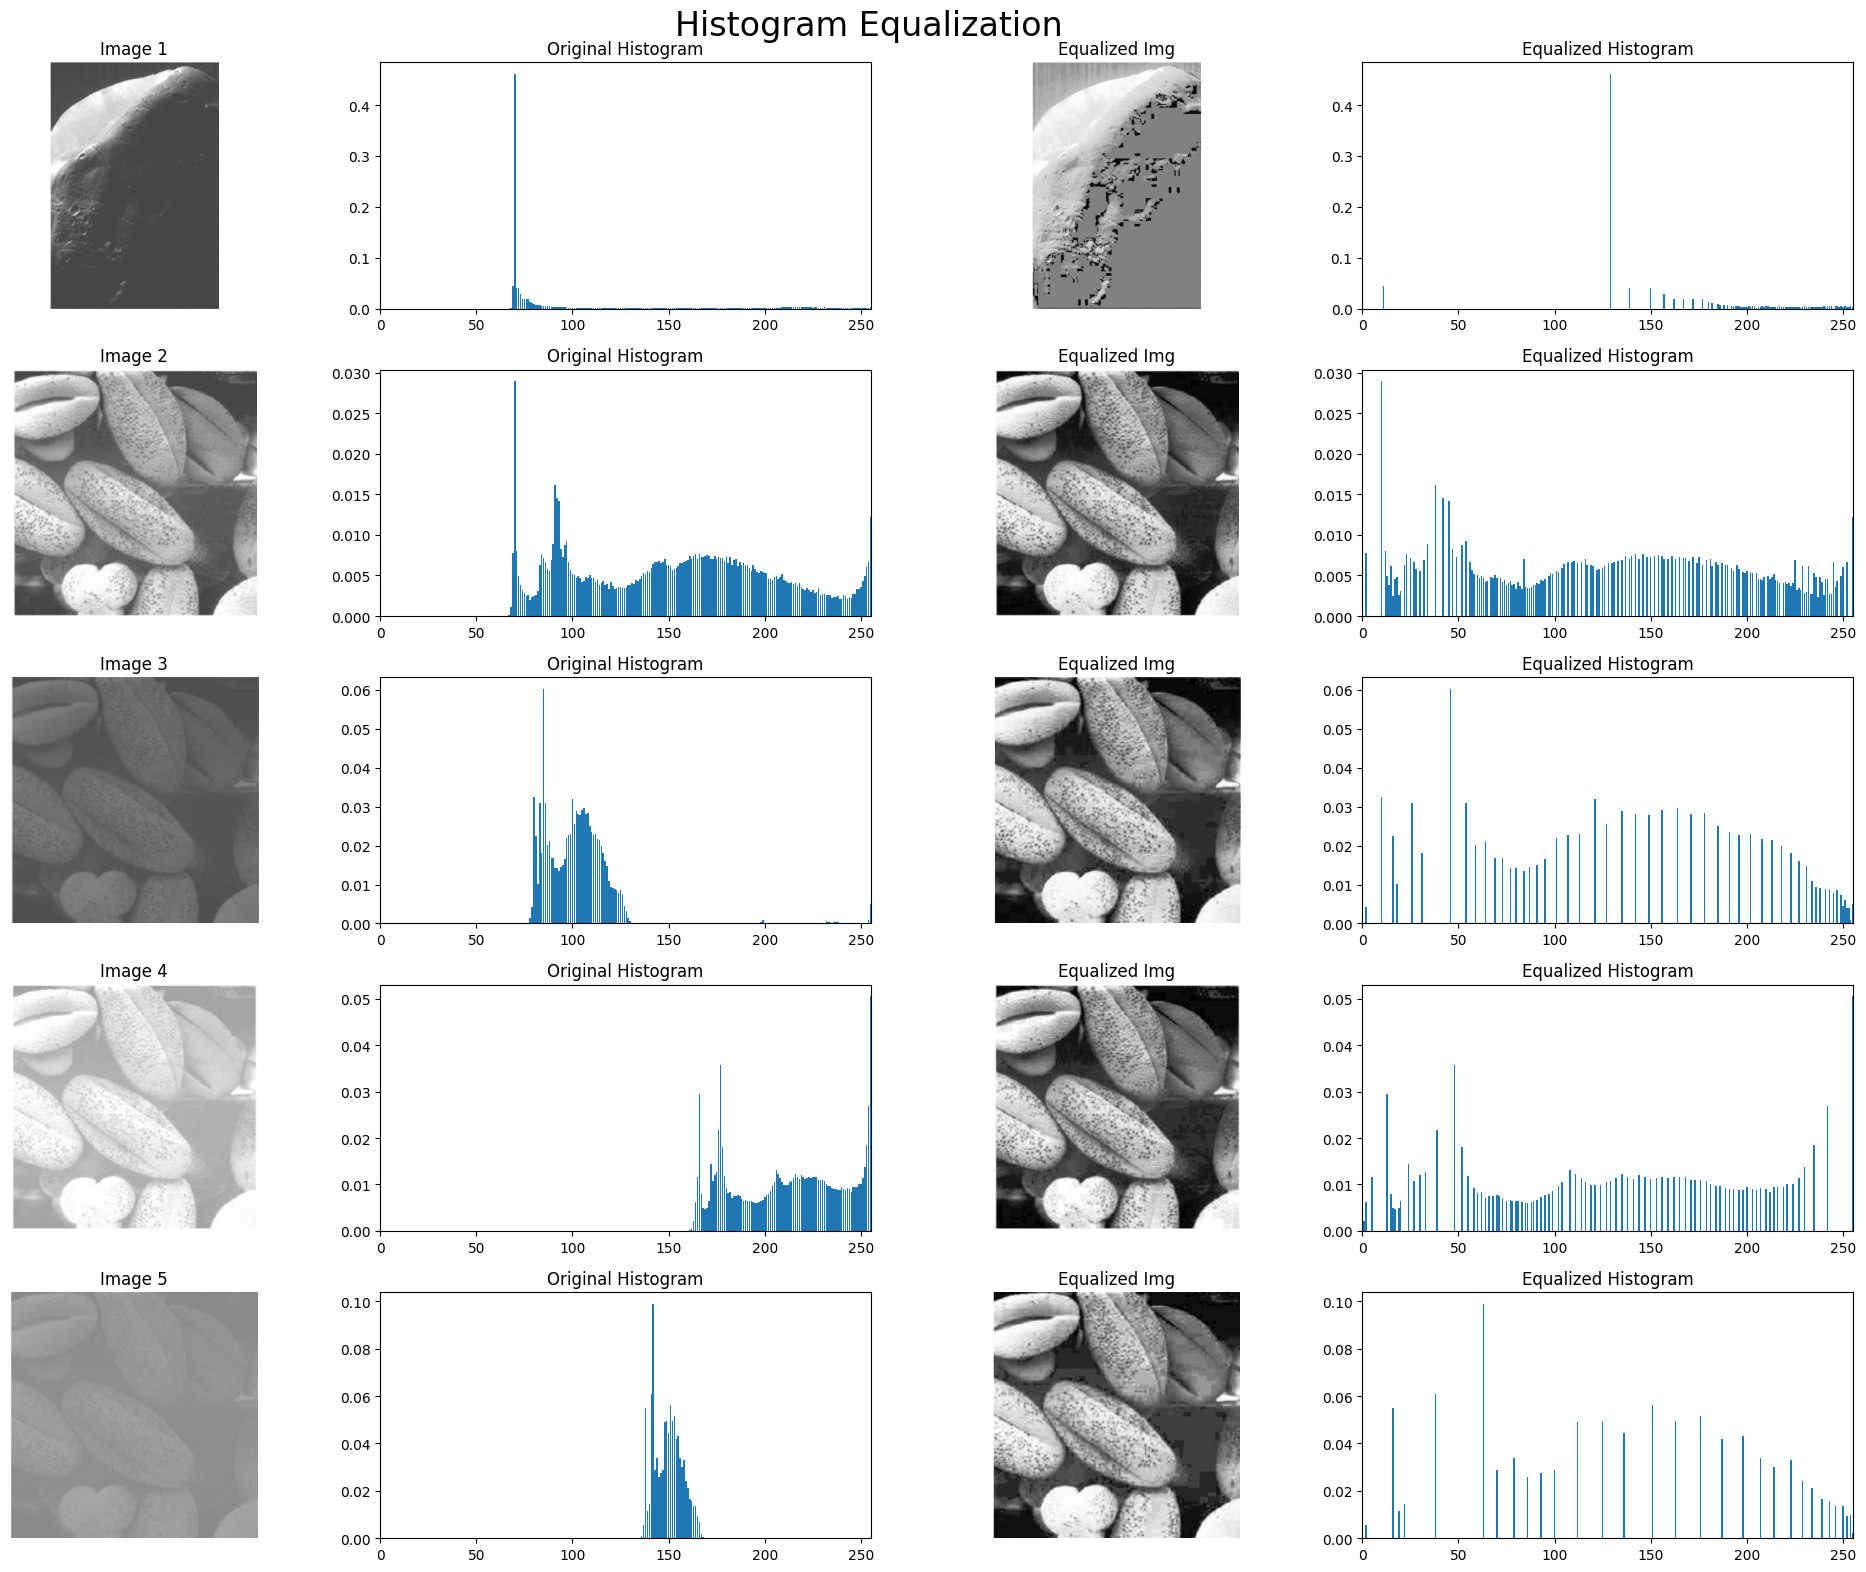

In [3]:
fig, axes = plt.subplots(5, 4, figsize=(20, 16))
fig.suptitle("Histogram Equalization ", fontsize=24)

for col in range(5):
    img = cv2.imread(images[col], cv2.IMREAD_GRAYSCALE)
    axes[col, 0].imshow(img, cmap='gray', vmin=0, vmax=255)
    axes[col, 0].set_title(f"Image {col+1}")
    axes[col, 0].axis("off")

    axes[col, 1].bar(range(256), compute_histogram(img))
    axes[col, 1].set_xlim(0, 255)
    axes[col, 1].set_title("Original Histogram")

    axes[col, 2].imshow(histogram_equalization(img), cmap='gray', vmin=0, vmax=255)
    axes[col, 2].axis("off")
    axes[col, 2].set_title("Equalized Img")

    axes[col, 3].bar(range(256), compute_histogram(histogram_equalization(img)))
    axes[col, 3].set_xlim(0, 255)
    axes[col, 3].set_title("Equalized Histogram")

plt.tight_layout()
plt.show()